In [82]:
import polars as pl
import pandas as pd
import numpy as np
import itertools
from skbio.diversity import alpha_diversity 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statannotations.Annotator import Annotator
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [27]:
ena_meta = pl.read_csv("ena_meta.tsv", separator="\t").to_pandas()
ena_meta

,run_accession,study_accession,sample_accession,experiment_accession,tax_id,scientific_name,fastq_ftp,submitted_ftp,sra_ftp,bam_ftp
0,SRR25158175,PRJNA983538,SAMN35729566,SRX20906449,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/075/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/075/SRR25158...,None
1,SRR25158178,PRJNA983538,SAMN35729644,SRX20906446,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/078/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/078/SRR25158...,None
2,SRR25158180,PRJNA983538,SAMN35729642,SRX20906444,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/080/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/080/SRR25158...,None
3,SRR25158183,PRJNA983538,SAMN35729639,SRX20906441,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/083/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/083/SRR25158...,None
4,SRR25158186,PRJNA983538,SAMN35729565,SRX20906438,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/086/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/086/SRR25158...,None
...,...,...,...,...,...,...,...,...,...,...
358,SRR25158523,PRJNA983538,SAMN35729667,SRX20906464,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/023/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/023/SRR25158...,None
359,SRR25158526,PRJNA983538,SAMN35729665,SRX20906461,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/026/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/026/SRR25158...,None
360,SRR25158531,PRJNA983538,SAMN35729660,SRX20906456,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/031/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/031/SRR25158...,None
361,SRR25158534,PRJNA983538,SAMN35729657,SRX20906453,410658,soil metagenome,ftp.sra.ebi.ac.uk/vol1/fastq/SRR251/034/SRR251...,None,ftp.sra.ebi.ac.uk/vol1/srr/SRR251/034/SRR25158...,None


In [29]:
smag_meta = pl.read_excel('smag_metadata.xlsx',  read_options={"header_row": 1}).to_pandas()
smag_meta

,Sample,user_genome,mag_num,Project,Source,Nation,Continent,Ecosystem,Paired_seqs,Lat,Lon,Bioproject,Biosample,Depth
0,BL1_EDME210000091,BL1bin,14,Europe,In-house Data,Belgium,Europe,Forest,116863493,50.860000,4.720000,PRJNA983538,SAMN35729406,0-20 cm
1,BL2_EDME210000092,BL2bin,17,Europe,In-house Data,Belgium,Europe,Forest,116422300,50.860000,4.720000,PRJNA983538,SAMN35729407,0-20 cm
2,BL3_EDME210000093,BL3bin,15,Europe,In-house Data,Belgium,Europe,Grassland,105333569,50.870000,4.710000,PRJNA983538,SAMN35729408,0-20 cm
3,China_S1,S1rebin,6,China2018,In-house Data,China,Asia,Agricultural Land,184365852,34.767778,111.769167,PRJNA983538,SAMN35729560,0-20 cm
4,China_S10,S10rbin,6,China2018,In-house Data,China,Asia,Wetland,136582694,34.643333,113.570556,PRJNA983538,SAMN35729561,0-20 cm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,Z4xia_BDME190026002,Z4xia_Bbin,14,hzbay,In-house Data,China,Asia,Wetland,68312396,30.590000,121.090000,PRJNA983538,SAMN35729505,0-20 cm
3300,Z5jian_BDME190601154,Z5jian_bin,7,hzbay,In-house Data,China,Asia,Wetland,78744756,30.590000,121.090000,PRJNA983538,SAMN35729506,0-20 cm
3301,Z5tu_BDME190025995,Z5tu_BDME190025995,0,hzbay,In-house Data,China,Asia,Grassland,89931682,30.590000,121.090000,PRJNA983538,SAMN35729507,0-20 cm
3302,Z5W_BDME190025934,Z5W_BDMbin,13,hzbay,In-house Data,China,Asia,Wetland,43199356,30.590000,121.090000,PRJNA983538,SAMN35729508,0-20 cm


In [32]:
smag_meta = pd.merge(smag_meta,ena_meta[['run_accession','sample_accession']],left_on='Biosample', right_on='sample_accession', how='left')
smag_meta

,Sample,user_genome,mag_num,Project,Source,Nation,Continent,Ecosystem,Paired_seqs,Lat,Lon,Bioproject,Biosample,Depth,run_accession,sample_accession
0,BL1_EDME210000091,BL1bin,14,Europe,In-house Data,Belgium,Europe,Forest,116863493,50.860000,4.720000,PRJNA983538,SAMN35729406,0-20 cm,SRR25158537,SAMN35729406
1,BL2_EDME210000092,BL2bin,17,Europe,In-house Data,Belgium,Europe,Forest,116422300,50.860000,4.720000,PRJNA983538,SAMN35729407,0-20 cm,SRR25158536,SAMN35729407
2,BL3_EDME210000093,BL3bin,15,Europe,In-house Data,Belgium,Europe,Grassland,105333569,50.870000,4.710000,PRJNA983538,SAMN35729408,0-20 cm,SRR25158457,SAMN35729408
3,China_S1,S1rebin,6,China2018,In-house Data,China,Asia,Agricultural Land,184365852,34.767778,111.769167,PRJNA983538,SAMN35729560,0-20 cm,SRR25158273,SAMN35729560
4,China_S10,S10rbin,6,China2018,In-house Data,China,Asia,Wetland,136582694,34.643333,113.570556,PRJNA983538,SAMN35729561,0-20 cm,SRR25158433,SAMN35729561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,Z4xia_BDME190026002,Z4xia_Bbin,14,hzbay,In-house Data,China,Asia,Wetland,68312396,30.590000,121.090000,PRJNA983538,SAMN35729505,0-20 cm,SRR25158336,SAMN35729505
3300,Z5jian_BDME190601154,Z5jian_bin,7,hzbay,In-house Data,China,Asia,Wetland,78744756,30.590000,121.090000,PRJNA983538,SAMN35729506,0-20 cm,SRR25158441,SAMN35729506
3301,Z5tu_BDME190025995,Z5tu_BDME190025995,0,hzbay,In-house Data,China,Asia,Grassland,89931682,30.590000,121.090000,PRJNA983538,SAMN35729507,0-20 cm,SRR25158439,SAMN35729507
3302,Z5W_BDME190025934,Z5W_BDMbin,13,hzbay,In-house Data,China,Asia,Wetland,43199356,30.590000,121.090000,PRJNA983538,SAMN35729508,0-20 cm,SRR25158438,SAMN35729508


In [33]:
smag_diversity = pl.read_csv('results/SMAG_all.csv').to_pandas()
smag_diversity

,sample,trimmed_mean_chao1,Shannon_index,study
0,SRR25158392,1927.848649,7.251344,SMAG
1,SRR25158337,1425.152405,7.581498,SMAG
2,SRR25158308,2336.727093,7.719768,SMAG
3,SRR25158470,2205.312482,7.450533,SMAG
4,SRR25158524,2354.582488,7.749928,SMAG
...,...,...,...,...
358,SRR25158408,2985.325175,7.408912,SMAG
359,SRR25158510,2519.255612,7.439482,SMAG
360,SRR25158247,2962.934708,7.979170,SMAG
361,SRR25158260,2582.389565,7.287523,SMAG


In [39]:
smag_diversity = pd.merge(smag_diversity,smag_meta[['run_accession','Ecosystem', 'Nation', 'Continent']],left_on='sample', right_on='run_accession', how='left')

In [56]:
shanghai_diversity = pl.read_csv('results/shanghai_all.csv').to_pandas()
shanghai_diversity["Ecosystem"] = "Urban"

In [57]:
df = pd.concat([shanghai_diversity, smag_diversity])
df

,sample,trimmed_mean_chao1,Shannon_index,study,Ecosystem,run_accession,Nation,Continent
0,SNJ20_350,4891.470368,7.132481,Urban_soil,Urban,NaN,NaN,NaN
1,CPSNJ19_350,2902.109552,7.075629,Urban_soil,Urban,NaN,NaN,NaN
2,20_350,3711.185216,7.172367,Urban_soil,Urban,NaN,NaN,NaN
3,19_350,3464.550349,7.279998,Urban_soil,Urban,NaN,NaN,NaN
4,SNJ16_350,4674.761951,7.258722,Urban_soil,Urban,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
358,SRR25158408,2985.325175,7.408912,SMAG,Wetland,SRR25158408,China,Asia
359,SRR25158510,2519.255612,7.439482,SMAG,Agricultural Land,SRR25158510,China,Asia
360,SRR25158247,2962.934708,7.979170,SMAG,Forest,SRR25158247,China,Asia
361,SRR25158260,2582.389565,7.287523,SMAG,Agricultural Land,SRR25158260,United Kingdom,Europe


/tmp/ipykernel_4873/3375660518.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


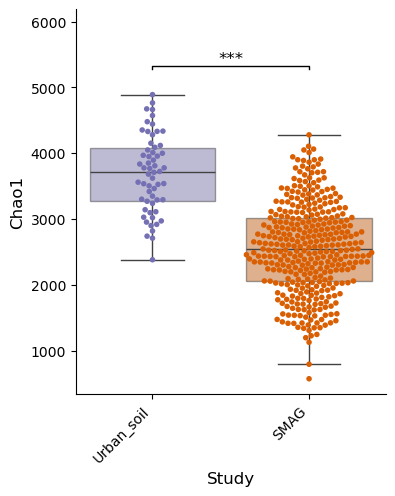

In [94]:
custom_palette = {
    'Urban_soil': '#7570b3',
    'SMAG': '#d95f02',
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="study", y="trimmed_mean_chao1", color='white', hue="study", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax)

sns.swarmplot(data=df, x="study", y="trimmed_mean_chao1", hue="study", 
             palette=custom_palette, ax=ax,size=4)

tukey = pairwise_tukeyhsd(endog=df['trimmed_mean_chao1'], groups=df['study'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        group1 = row[0]
        group2 = row[1]
        p_val = float(row[3])
        significant_pairs.append( (group1, group2, p_val) )

group_order = df['study'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['trimmed_mean_chao1'].max()
y_min = df['trimmed_mean_chao1'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Chao1', fontsize=12)
ax.set_xlabel('Study', fontsize=12)

plt.savefig("chao1.svg")

/tmp/ipykernel_4873/508178977.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


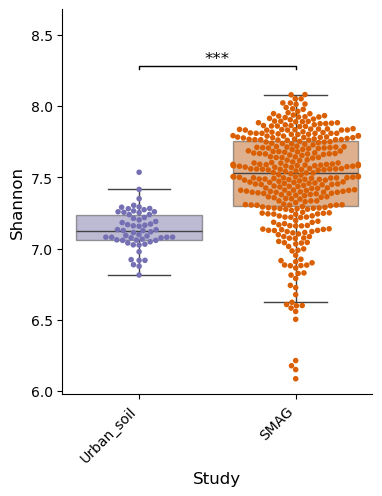

In [95]:
custom_palette = {
    'Urban_soil': '#7570b3',
    'SMAG': '#d95f02',
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="study", y="Shannon_index", color='white', hue="study", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax)

sns.swarmplot(data=df, x="study", y="Shannon_index", hue="study", 
             palette=custom_palette, ax=ax,size=4)

tukey = pairwise_tukeyhsd(endog=df['Shannon_index'], groups=df['study'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        group1 = row[0]
        group2 = row[1]
        p_val = float(row[3])
        significant_pairs.append( (group1, group2, p_val) )

group_order = df['study'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['Shannon_index'].max()
y_min = df['Shannon_index'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Shannon', fontsize=12)
ax.set_xlabel('Study', fontsize=12)

plt.savefig("shannon.svg")

/tmp/ipykernel_4873/2576599425.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


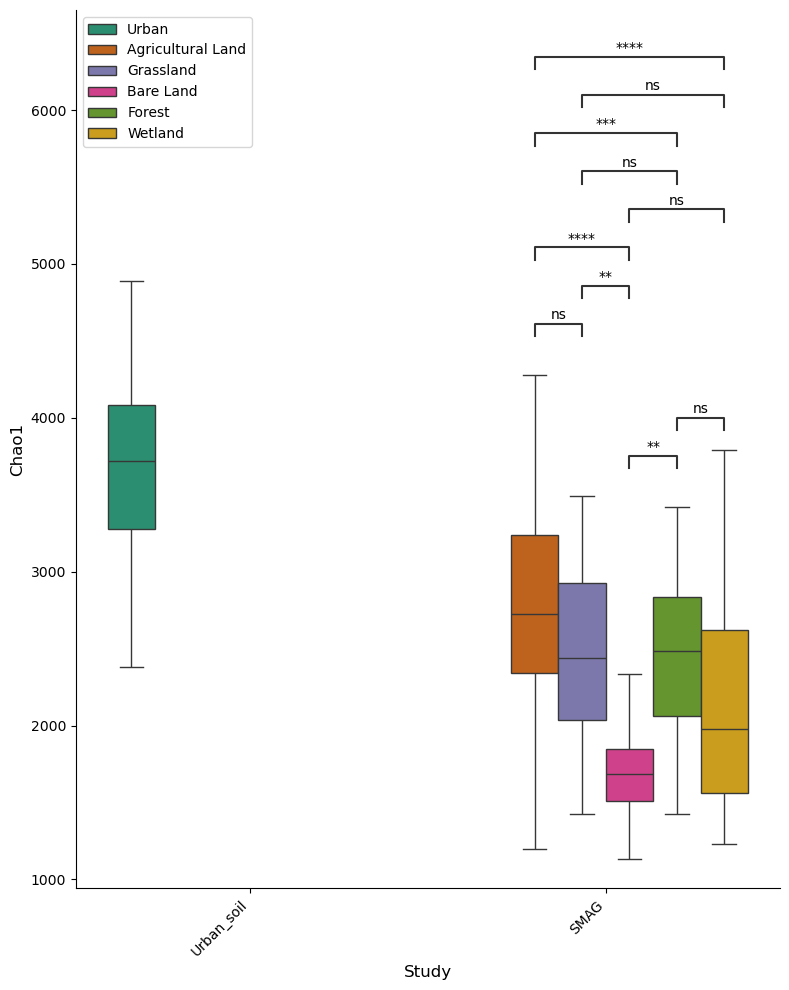

In [96]:
fig, ax = plt.subplots(figsize=(8, 10))

sns.boxplot(
    data=df,
    x="study",
    y="trimmed_mean_chao1",
    hue="Ecosystem",
    palette="Dark2",
    showfliers=False,
    ax=ax
)

pairs = []
pvalues = []

# Run Tukey per study
for study in df["study"].unique():

    df_sub = df[df["study"] == study]
    ecosystems = df_sub["Ecosystem"].unique()

    if len(ecosystems) < 2:
        continue  # Skip Urban_soil (only 1 ecosystem)

    tukey = pairwise_tukeyhsd(
        endog=df_sub["trimmed_mean_chao1"],
        groups=df_sub["Ecosystem"],
        alpha=0.05
    )

    results = pd.DataFrame(
        data=tukey.summary().data[1:], 
        columns=tukey.summary().data[0]
    )

    for _, row in results.iterrows():
        group1 = row["group1"]
        group2 = row["group2"]
        p_adj = float(row["p-adj"])

        pairs.append(((study, group1), (study, group2)))
        pvalues.append(p_adj)

annotator = Annotator(
    ax,
    pairs,
    data=df,
    x="study",
    y="trimmed_mean_chao1",
    hue="Ecosystem"
)

annotator.configure(
    test=None,              # IMPORTANT
    text_format='star',
    loc='inside',
    verbose=0
)

annotator.set_pvalues(pvalues)
annotator.annotate()

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Chao1', fontsize=12)
ax.set_xlabel('Study', fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("chao1_ecosystems.svg")

/tmp/ipykernel_4873/1742267510.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


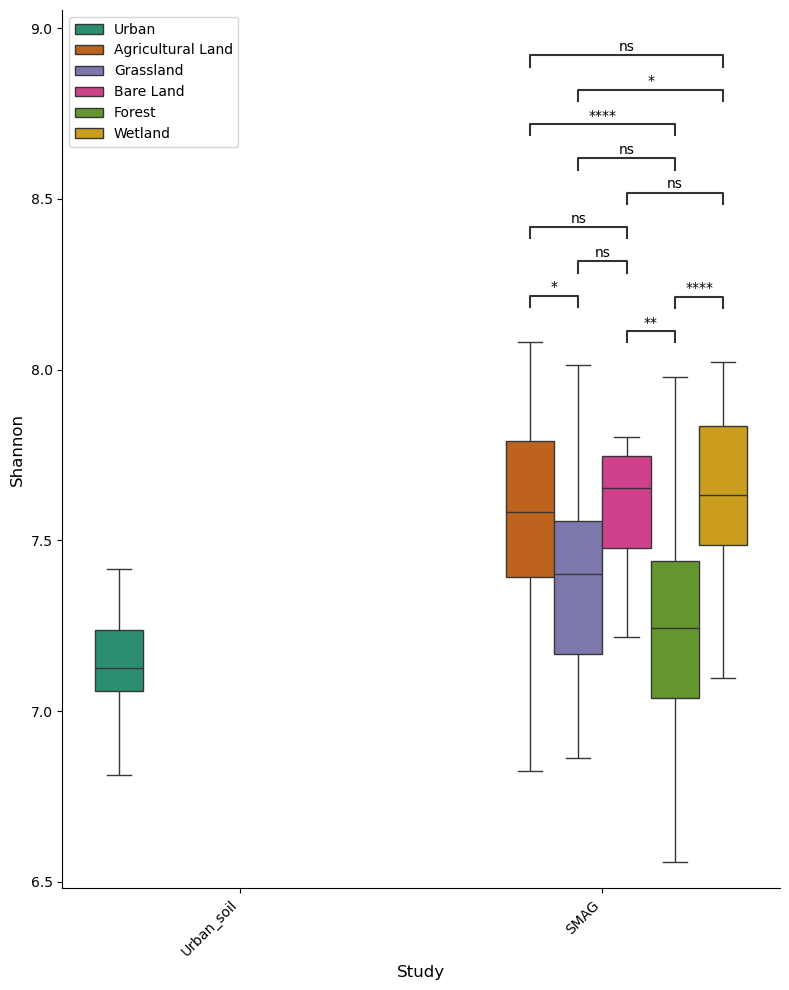

In [97]:
ig, ax = plt.subplots(figsize=(8, 10))

sns.boxplot(
    data=df,
    x="study",
    y="Shannon_index",
    hue="Ecosystem",
    palette="Dark2",
    showfliers=False,
    ax=ax
)

pairs = []
pvalues = []

# Run Tukey per study
for study in df["study"].unique():

    df_sub = df[df["study"] == study]
    ecosystems = df_sub["Ecosystem"].unique()

    if len(ecosystems) < 2:
        continue  # Skip Urban_soil (only 1 ecosystem)

    tukey = pairwise_tukeyhsd(
        endog=df_sub["Shannon_index"],
        groups=df_sub["Ecosystem"],
        alpha=0.05
    )

    results = pd.DataFrame(
        data=tukey.summary().data[1:], 
        columns=tukey.summary().data[0]
    )

    for _, row in results.iterrows():
        group1 = row["group1"]
        group2 = row["group2"]
        p_adj = float(row["p-adj"])

        pairs.append(((study, group1), (study, group2)))
        pvalues.append(p_adj)

annotator = Annotator(
    ax,
    pairs,
    data=df,
    x="study",
    y="Shannon_index",
    hue="Ecosystem"
)

annotator.configure(
    test=None,              # IMPORTANT
    text_format='star',
    loc='inside',
    verbose=0
)

annotator.set_pvalues(pvalues)
annotator.annotate()

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Shannon', fontsize=12)
ax.set_xlabel('Study', fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("shannon_ecosystems.svg")